In [2]:
import numpy as np
import pandas as pd

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [4]:
data= pd.read_csv("../Dataset/iris.csv", index_col="Id")
data.head()

,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X= data.drop("Species", axis=1).to_numpy()
y= data[["Species"]].to_numpy()


In [6]:
scaler= StandardScaler()
onehot_encoder= OneHotEncoder(sparse_output=False)

enc_y= onehot_encoder.fit_transform(y)
scaled_X = scaler.fit_transform(X)

In [7]:
cat_array= onehot_encoder.categories_[0]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, enc_y, test_size=0.2, shuffle= True, stratify=enc_y,random_state=999
)

### Model creation and compile

In [9]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD, Adam


In [10]:
inp_shape= X_train.shape[1]
num_classes = y_train.shape[1]

In [11]:
model= Sequential()

model.add(Input(shape =(inp_shape,))) #input layer

model.add(Dense(10, activation= "relu")) #hidden layer
model.add(Dense(6, activation= "relu")) #hidden layer

model.add(Dense(num_classes,activation= "softmax")) #output layer

model.compile(
    optimizer=Adam(learning_rate=0.1), loss= "categorical_crossentropy", metrics= ["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history= model.fit(
    X_train, y_train, epochs=50, batch_size=64, verbose=1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7667 - loss: 0.8126
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8833 - loss: 0.3533 
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8417 - loss: 0.2674
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8917 - loss: 0.2431
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9167 - loss: 0.1927
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9333 - loss: 0.1588
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9667 - loss: 0.1092
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9583 - loss: 0.0850
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9750 - loss: 0.0741
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9750 - loss: 0.0591
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9583 - loss: 0.0628
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9667 - loss: 0.0589 

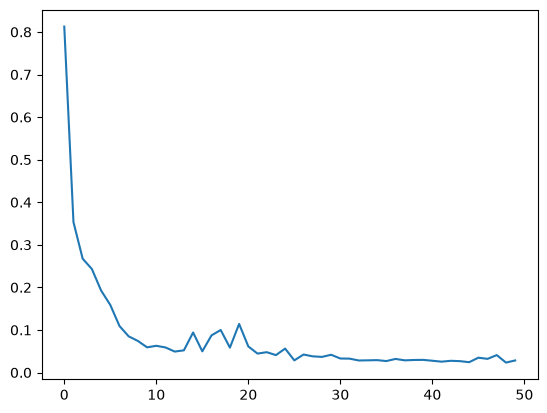

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9667 - loss: 0.1573


0.9666666388511658

In [16]:
y_pred= np.argmax(model.predict(X_test), axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [17]:
y_true= np.argmax(y_test, axis=1)
y_true

array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
confusion_matrix(y_true, y_pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

In [19]:
accuracy_score(y_true, y_pred)

0.9666666666666667

In [20]:
recall_score(y_true, y_pred, average="weighted")

0.9666666666666667

In [21]:
f1_score(y_true, y_pred, average="macro")

0.9665831244778613

In [22]:
cat_array[np.argmax(model.predict(
        np.array([[5.1,3.5,1.4,0.2]])
    ))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


'Iris-virginica'

In [23]:
import pickle #joblib

In [25]:
to_package = {
    "scaler" : scaler,
    "encoder" : onehot_encoder,
    "model" : model
}

with open("iris_classifier.keras", "wb") as file:
    pickle.dump(to_package, file)